In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sdv
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency

### Loading the CTGAN synthesizer

In [8]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer.load(filepath='../synthesizers/first_synthesizer.pkl')


In [9]:
real_df = pd.read_csv("../data/full_data_cleaned.csv")
synthetic_df = synthesizer.sample(num_rows=len(real_df))

In [ ]:
print(synthetic_df['FraudFound_P'].head(10))
print(real_df['FraudFound_P'].head(10))

In [14]:
real_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  15420 non-null  object 
 1   AccidentArea          15420 non-null  int64  
 2   DayOfWeekClaimed      15420 non-null  object 
 3   MonthClaimed          15420 non-null  object 
 4   WeekOfMonthClaimed    15420 non-null  float64
 5   Sex                   15420 non-null  int64  
 6   MaritalStatus         15420 non-null  object 
 7   Fault                 15420 non-null  int64  
 8   PolicyType            15420 non-null  object 
 9   VehicleCategory       15420 non-null  object 
 10  VehiclePrice          15420 non-null  object 
 11  FraudFound_P          15420 non-null  float64
 12  Deductible            15420 non-null  float64
 13  DriverRating          15420 non-null  float64
 14  Days_Policy_Accident  15420 non-null  object 
 15  Days_Policy_Claim  

### Kolmogorov-Smirnov similarity test for numerical columns

In [17]:
real_df_copy = real_df.copy()
synthetic_df_copy = synthetic_df.copy()
numerical_cols = real_df_copy.select_dtypes(include='number').columns
print(numerical_cols)

Index(['AccidentArea', 'WeekOfMonthClaimed', 'Sex', 'Fault', 'FraudFound_P',
       'Deductible', 'DriverRating', 'PoliceReportFiled', 'WitnessPresent',
       'AgentType', 'PolicyMismatchFlag'],
      dtype='object')


In [18]:
ks_results = {}
for col in numerical_cols:
    r = real_df_copy[col]
    s = synthetic_df_copy[col]
    stat, p = ks_2samp(r, s)
    ks_results[col] = (stat, p)

for col, (stat, p) in ks_results.items():
    print(f"{col}: KS stat={stat:.4f}, p={p:.4f}")

AccidentArea: KS stat=0.0987, p=0.0000
WeekOfMonthClaimed: KS stat=0.1254, p=0.0000
Sex: KS stat=0.2117, p=0.0000
Fault: KS stat=0.0765, p=0.0000
FraudFound_P: KS stat=0.0183, p=0.0114
Deductible: KS stat=0.0524, p=0.0000
DriverRating: KS stat=0.2547, p=0.0000
PoliceReportFiled: KS stat=0.0064, p=0.9063
WitnessPresent: KS stat=0.0219, p=0.0012
AgentType: KS stat=0.0444, p=0.0000
PolicyMismatchFlag: KS stat=0.0269, p=0.0000


Strongest synthetic matches
- PoliceReportFiled (KS = 0.006)
- WitnessPresent (0.022)
- FraudFound_P (0.018)
- Deductible (0.052)
- AccidentArea (0.098)

Moderate match between synthetic and real data
- WeekOfMonthClaimed (0.125)

Weak matches (problematic)
- Sex (0.212)
- DriverRating (0.255)

### Chi-Square test for similarity of categorical columns

In [23]:
from scipy.stats import chisquare

cat_cols = real_df_copy.select_dtypes(exclude='number').columns
chi_results = {}

for col in cat_cols:
    real_counts = real_df_copy[col].value_counts()
    synth_counts = synthetic_df_copy[col].value_counts()
    print(pd.DataFrame({"real": real_counts, "synthetic": synth_counts}).fillna(0))

    both = pd.concat([real_counts, synth_counts], axis=1, sort=True).fillna(0)
    chi2, p, _, _ = chi2_contingency(both.T)
    chi_results[col] = p

for col,p in chi_results.items():
    print(f"{col}: chi-square p={p:.4f}")

           real  synthetic
Accura      472        670
BMW          15         27
Chevrolet  1681       1216
Dodge       109        101
Ferrari       2          5
Ford        450        776
Honda      2801       2764
Jaguar        6         18
Lexus         1          5
Mazda      2354       1194
Mecedes       4         12
Mercury      83         96
Nisson       30         55
Pontiac    3837       3964
Porche        5         16
Saab        108        186
Saturn       58         78
Toyota     3121       3923
VW          283        314
           real  synthetic
0             1         19
Friday     2497       1720
Monday     3757       2407
Saturday    127        115
Sunday       52        116
Thursday   2660       2948
Tuesday    3375       5209
Wednesday  2951       2886
     real  synthetic
0       1          7
Apr  1271       2104
Aug  1126        752
Dec  1146       1277
Feb  1287       1463
Jan  1446        948
Jul  1225       1346
Jun  1293        948
Mar  1348        954
May  14

Chi-square might not be the best metric for evaluating GAN performance in creating synthetic data that has similar distributions for categorical variables, since some categorical variables distributions differ by 50 to 100%, between real and synthetic data created by the CTGAN. This makes the chi-square statistic enormous and therefore the p-value extremely small, which is why it shows 0.0000.

### Total Variation Distance metric for categorical variables

In [25]:
cat_cols = real_df_copy.select_dtypes(exclude='number').columns
tvd_results = {}

for col in cat_cols:
    real_counts = real_df_copy[col].value_counts()
    synth_counts = synthetic_df_copy[col].value_counts()

    tvd = 0.5 * (abs(real_counts - synth_counts).sum() / real_counts.sum())
    tvd_results[col]=tvd

for col,t in tvd_results.items():
    print(f"{col}: total variation distance ={t:.4f}")

Make: total variation distance =0.1083
DayOfWeekClaimed: total variation distance =0.1429
MonthClaimed: total variation distance =0.1722
MaritalStatus: total variation distance =0.0427
PolicyType: total variation distance =0.0418
VehicleCategory: total variation distance =0.0167
VehiclePrice: total variation distance =0.0733
Days_Policy_Accident: total variation distance =0.0379
Days_Policy_Claim: total variation distance =0.0632
PastNumberOfClaims: total variation distance =0.1466
AgeOfVehicle: total variation distance =0.1160
AgeOfPolicyHolder: total variation distance =0.1320
NumberOfSuppliments: total variation distance =0.1154
AddressChange_Claim: total variation distance =0.0106
NumberOfCars: total variation distance =0.0185
BasePolicy: total variation distance =0.0300


Most categories should give a result around 0.1-0.3 for CTGAN, where a TVD of 0 is the best possible fit and a TVD of 1 is the worst possible fit. We see results from 0-0.2, which is a good sign for categorical variables.

### SDMetric: Distribution Similarity Metric

In [26]:
from sdmetrics.single_table import CSTest

score = CSTest.compute(real_df, synthetic_df)
print(score)

0.9857015781152118


Interpreting the SD Metric: 
- It measures how closely synthetic columns match real columns, and accounts for the similarities between each columns, and also accounts for sample size
- A score near 1 means that the numerical distributions match very well, that the categorical distributions are learned well, and that the model captures marginal distributions well too.

### Correlation Matrix to check if CTGAN preserved similarity between features

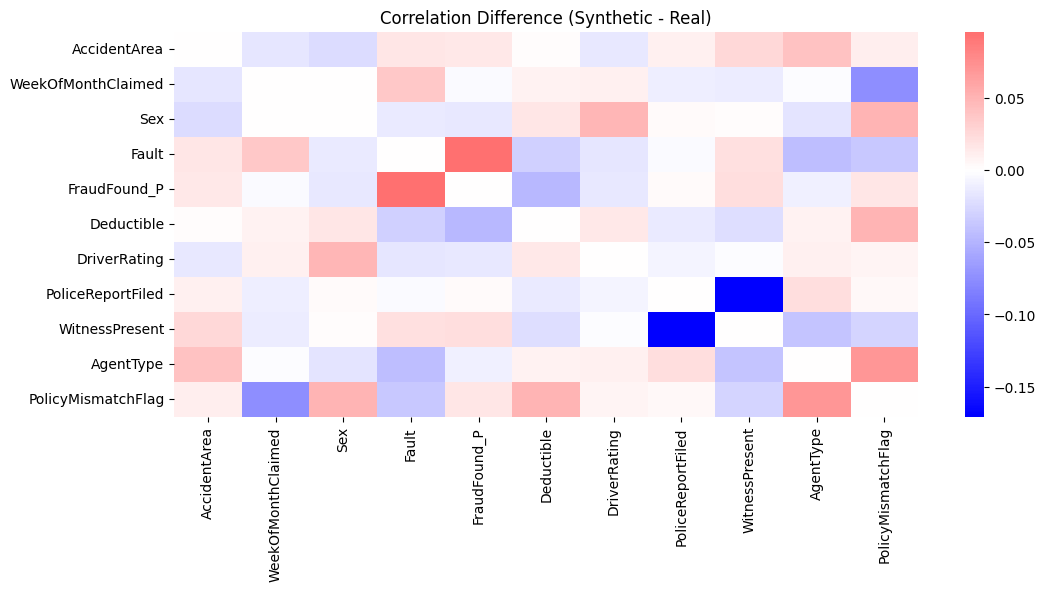

In [ ]:
real_corr = real_df.corr(numeric_only=True)
synth_corr = synthetic_df.corr(numeric_only=True)

plt.figure(figsize=(12,5))
sns.heatmap(synth_corr - real_corr, center=0, cmap="bwr")
plt.title("Correlation Difference (Synthetic-Real)")
plt.show()


Blue and red areas show correlation patterns CTGAN failed to reproduce: 
- In this matrix, we can see that the PoliceReportFiled and WitnessPresent correlation was harder to capture by the CTGAN
- Fault and FraudFound_P was also harder to capture

### Does synthetic data preserve the predictive structure of real data

In [36]:
target = "FraudFound_P"

real_encoded = pd.get_dummies(real_df)
synthetic_encoded = pd.get_dummies(synthetic_df)
synthetic_encoded = synthetic_encoded.reindex(columns=real_encoded.columns, fill_value=0)

# Train on synthetic
X_syn = synthetic_encoded.drop(columns=[target])
y_syn = synthetic_encoded[target]

clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_syn, y_syn)

# Test on real
X_real = real_encoded.drop(columns=[target])
y_real = real_encoded[target]

pred = clf.predict(X_real)
proba = clf.predict_proba(X_real)[:,1]

print(f"Accuracy: {accuracy_score(y_real, pred)}")
print(f"AUC: {roc_auc_score(y_real, proba)}")


Accuracy: 0.9399481193255512
AUC: 0.6906643590697698


- GAN has a pretty high accuracy score. 
- AUC lower than the same model trained on real data: generator might have missed key relationships (to be explored more)

### Visualizations

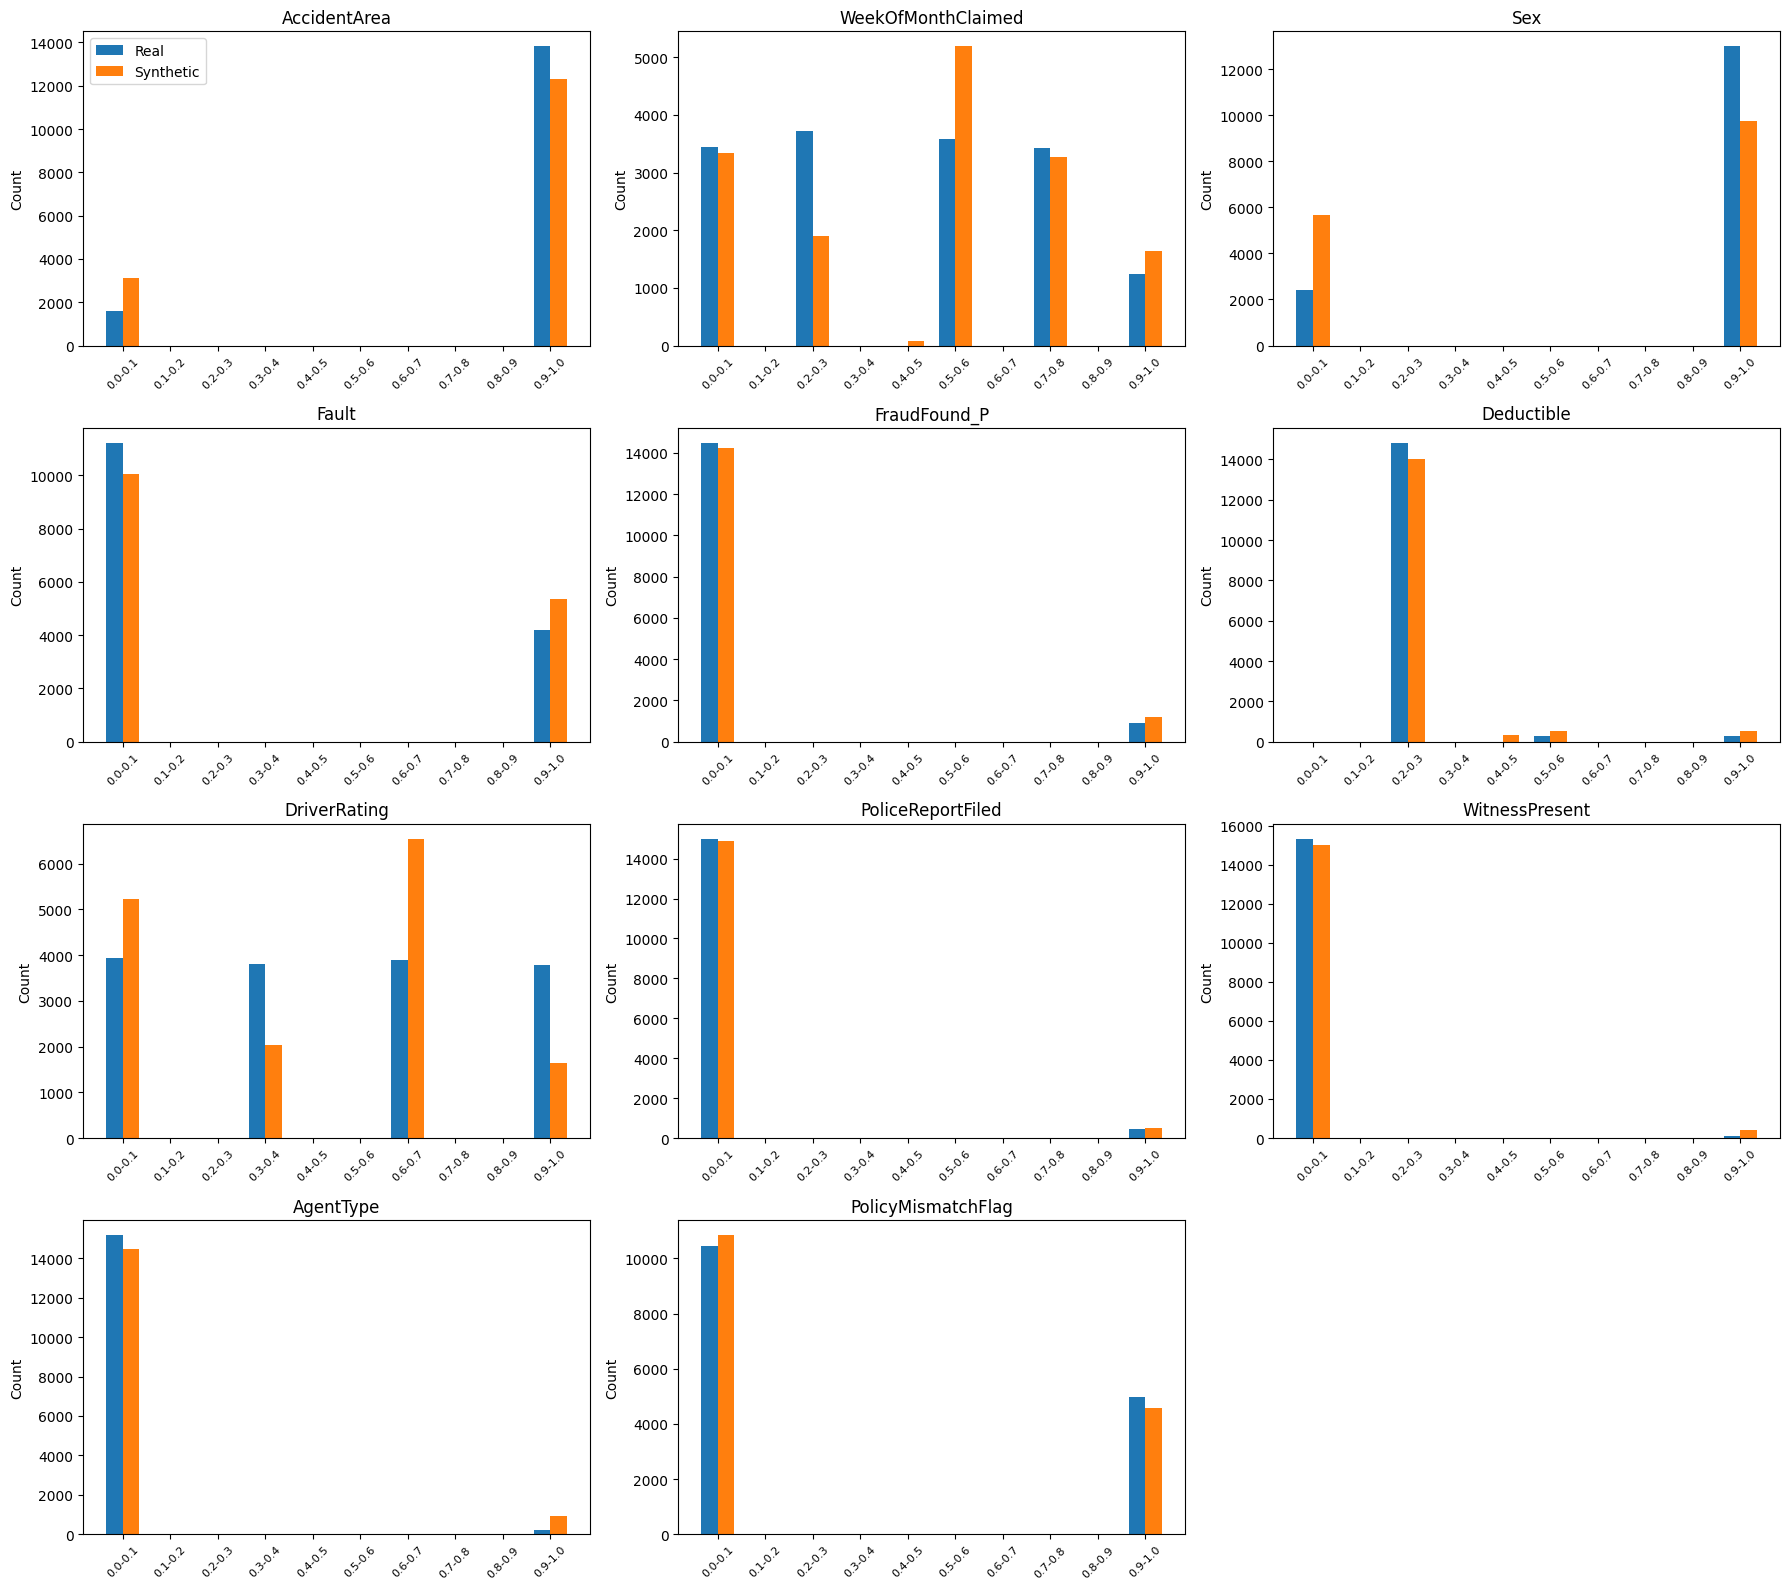

In [ ]:
bins = 10
n = len(numerical_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 6, rows * 4))

for i, col in enumerate(numerical_cols, 1):
    real_counts, bin_edges = np.histogram(real_df[col], bins=bins)
    synth_counts, _ = np.histogram(synthetic_df[col], bins=bin_edges)

    x = np.arange(len(real_counts))
    width = 0.35
    plt.subplot(rows, cols, i)

    plt.bar(x - width/2, real_counts, width, label='Real')
    plt.bar(x + width/2, synth_counts, width, label='Synthetic')

    plt.title(col)
    plt.xticks(x,
        [f"{bin_edges[j]:.1f}-{bin_edges[j+1]:.1f}" for j in range(len(bin_edges)-1)],
        rotation=45,
        fontsize=8)
    plt.ylabel("Count")

    if i == 1:
        plt.legend()

plt.tight_layout()
plt.show()

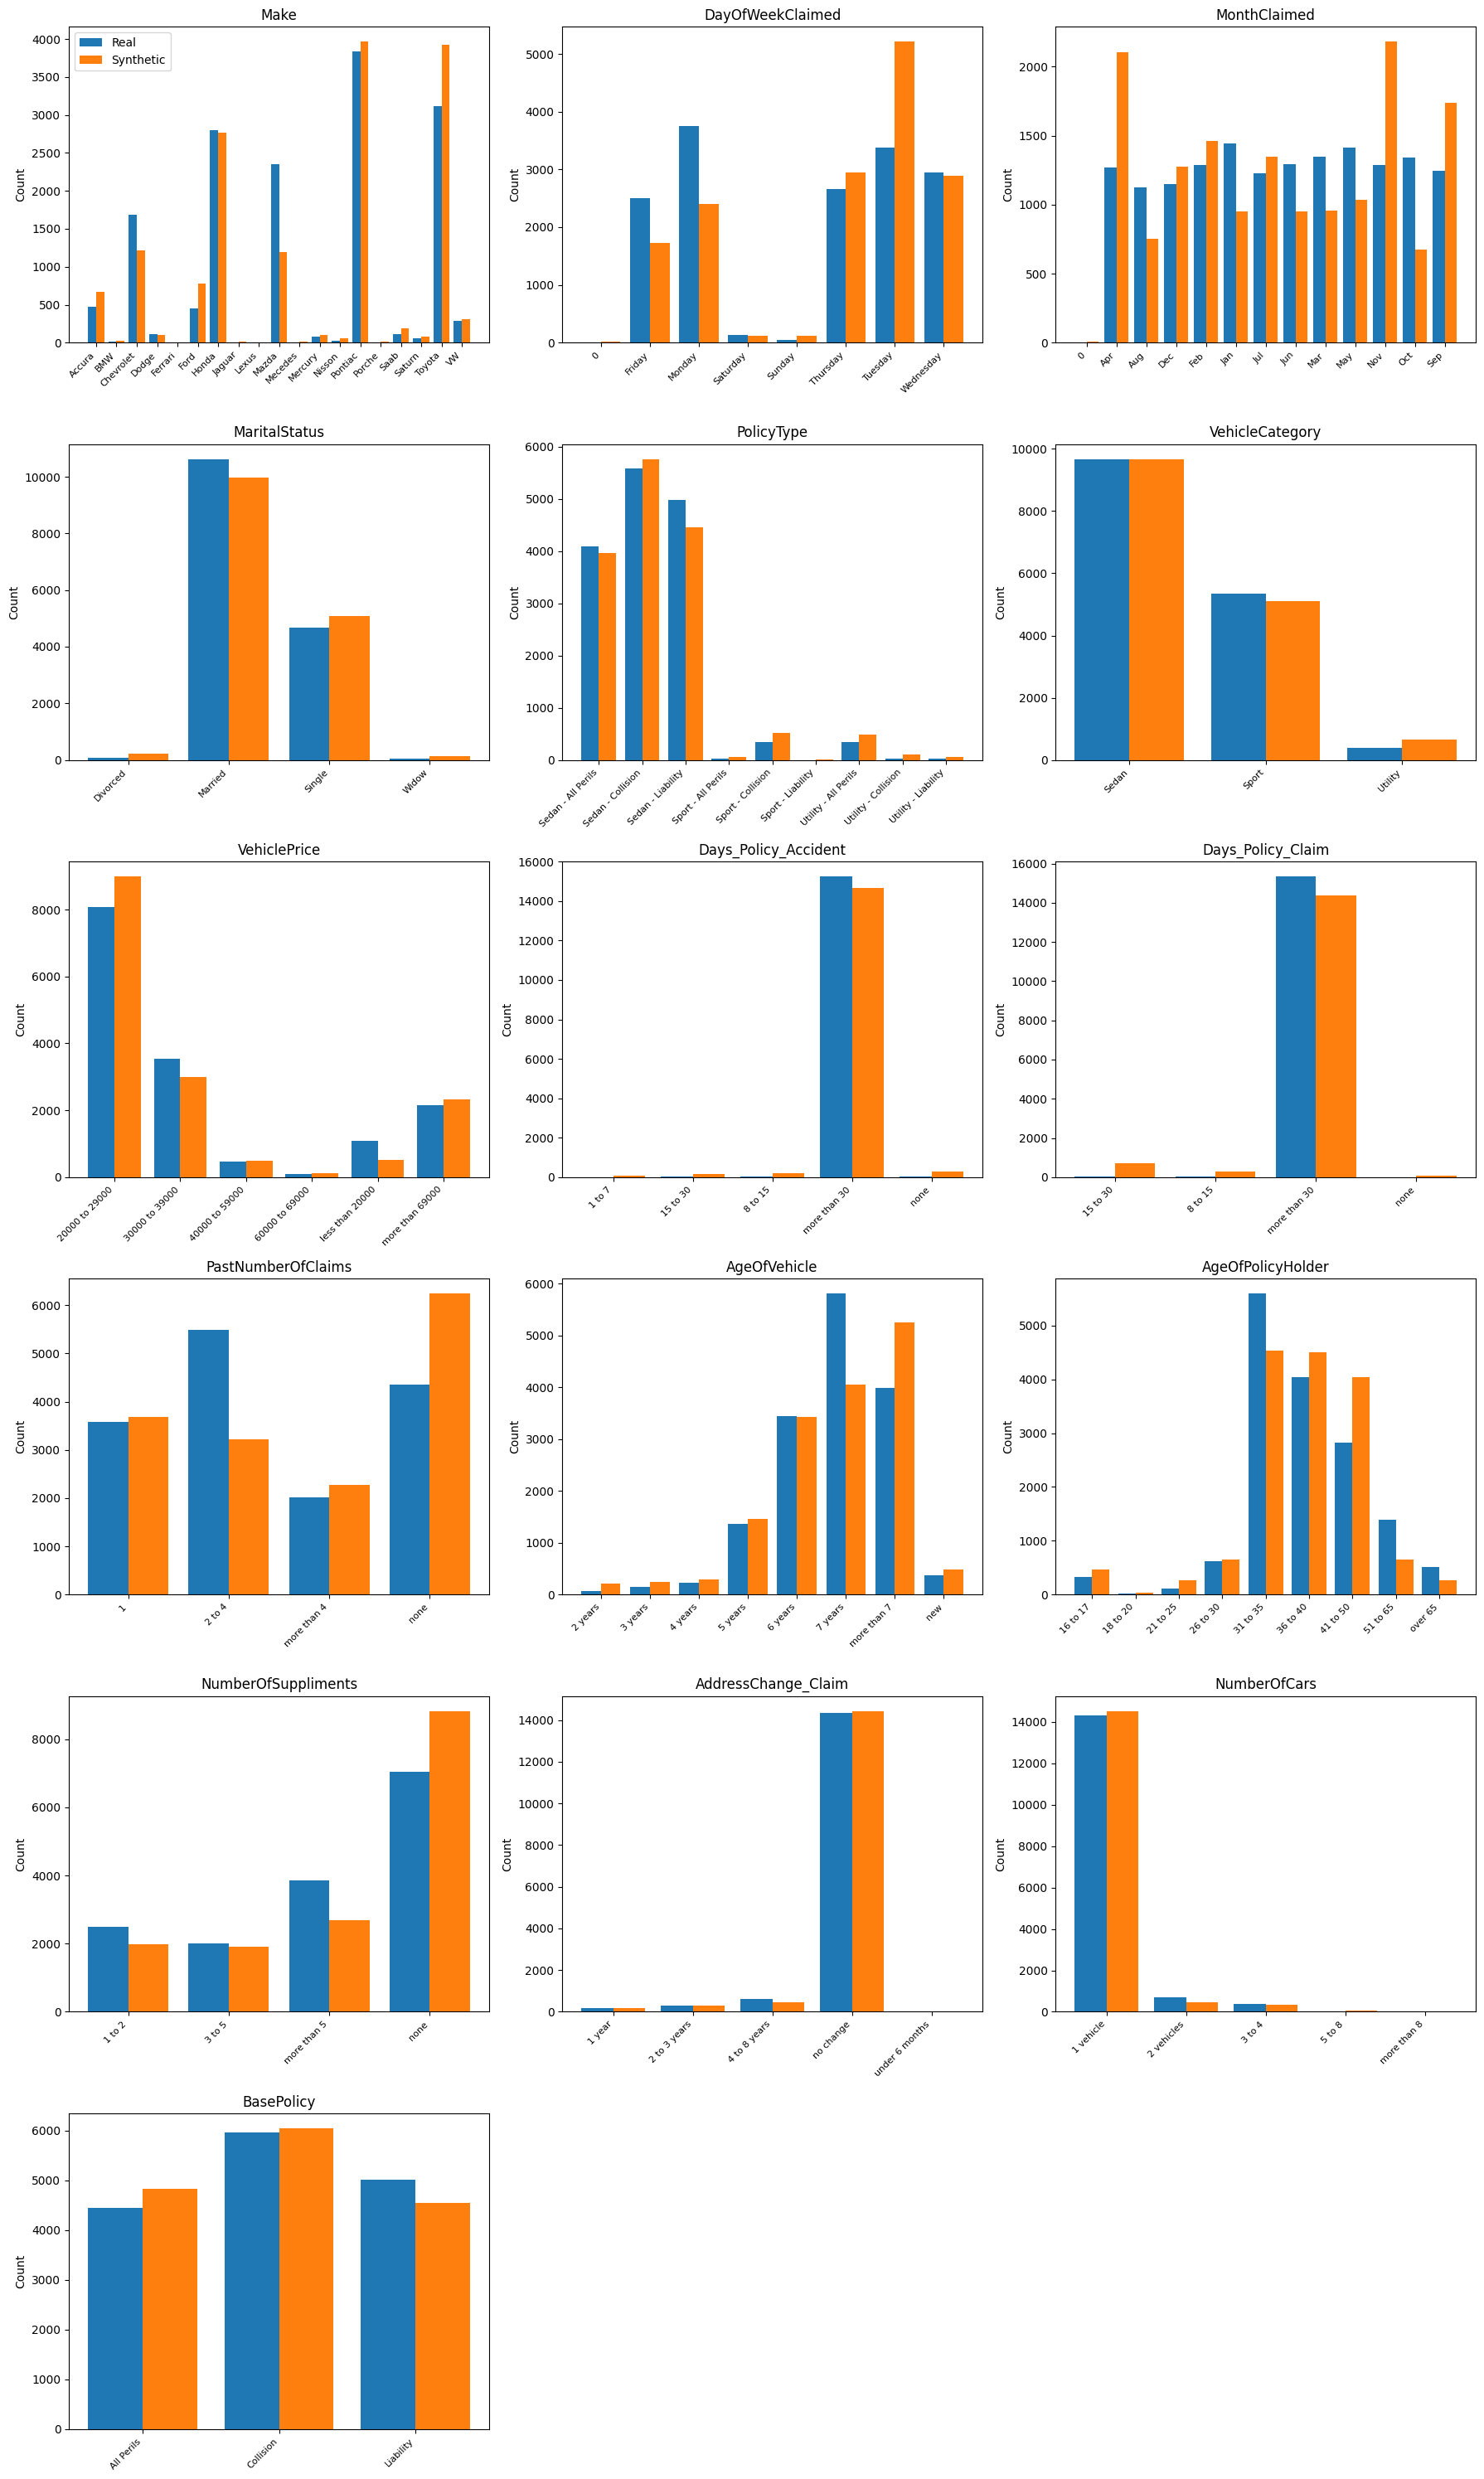

In [35]:
n = len(cat_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)

    real_counts = real_df[col].value_counts()
    synth_counts = synthetic_df[col].value_counts()

    categories = sorted(set(real_counts.index).union(set(synth_counts.index)))

    real_vals = [real_counts.get(cat, 0) for cat in categories]
    synth_vals = [synth_counts.get(cat, 0) for cat in categories]

    x = range(len(categories))
    width = 0.4

    plt.bar([p - width/2 for p in x], real_vals, width, label='Real')
    plt.bar([p + width/2 for p in x], synth_vals, width, label='Synthetic')

    plt.title(col)
    plt.xticks(x, categories, rotation=45, ha='right', fontsize=8)
    plt.ylabel("Count")

    if i == 1:
        plt.legend()

plt.tight_layout()
plt.show()